# explorative data analysis

In [2]:
# import modules 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
pd.set_option('display.float_format', '{:.2f}'.format)
from pathlib import Path



In [4]:
# load dataset

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.csv"
)

print(df.shape)
# df.head()


(57529, 30)


In [6]:
df.describe()

,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,follow_up_prompts,needs_follow_up,...,question_count,orthographic_error_rate,topic,topic_prob,embedding_novelty,topic_confidence,is_generic_topic,topic_size,topic_size_log,target_cost
count,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,...,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00
mean,176.59,496.31,16.62,8.31,737.40,4090.66,4828.05,7.52,7.33,0.73,...,0.60,0.05,0.43,0.56,0.76,0.56,0.40,24647.12,9.77,496.31
std,802.25,903.69,36.51,18.25,3076.31,10372.56,11669.88,1.35,18.43,0.44,...,2.96,0.07,4.37,0.31,0.14,0.31,0.49,8167.03,1.41,903.69
min,2.00,1.00,2.00,1.00,5.00,1.00,9.00,2.30,0.00,0.00,...,0.00,0.00,-1.00,0.00,0.37,0.00,0.00,51.00,3.95,1.00
25%,16.00,155.00,2.00,1.00,47.00,542.00,698.00,6.55,0.00,0.00,...,0.00,0.00,-1.00,0.30,0.66,0.30,0.00,22662.00,10.03,155.00
50%,34.00,329.00,6.00,3.00,142.00,1418.00,1763.00,7.48,2.00,1.00,...,0.00,0.02,-1.00,0.56,0.76,0.56,0.00,30054.00,10.31,329.00
75%,112.00,587.00,16.00,8.00,473.00,3762.00,4537.00,8.42,7.00,1.00,...,1.00,0.08,0.00,0.80,0.87,0.80,1.00,30054.00,10.31,587.00
max,79821.00,76828.00,972.00,486.00,168177.00,358980.00,360095.00,12.79,547.00,1.00,...,261.00,1.00,35.00,1.00,1.18,1.00,1.00,30054.00,10.31,76828.00


<Axes: >

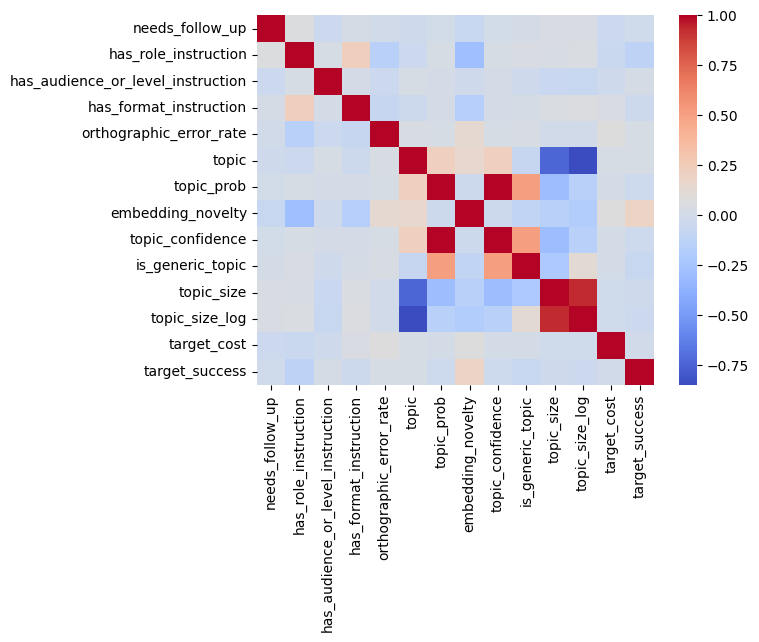

In [6]:
# correlations

sns.heatmap(df[['needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
        'orthographic_error_rate', 'topic', 'topic_prob',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success']].corr(), cmap="coolwarm")

In [7]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success'],
      dtype='str')

# features

### structure features

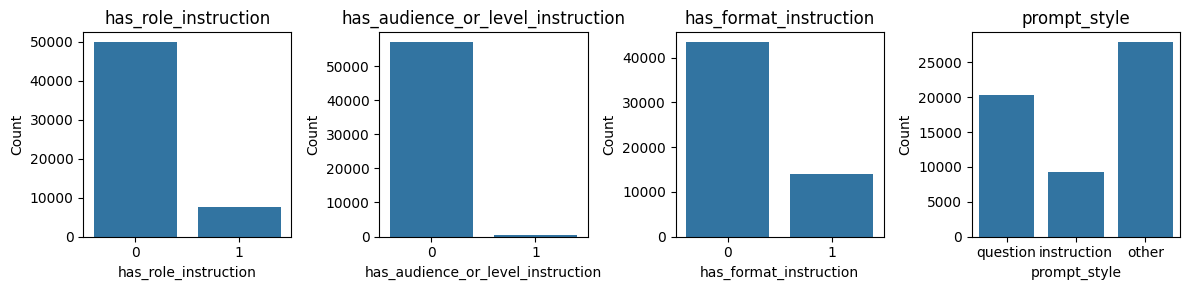

In [36]:

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes = axes.flatten()

prompt_design_features=['has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'prompt_style']


for i, feature in enumerate(prompt_design_features):
    sns.countplot(data=df, x=feature, ax=axes[i])
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()   


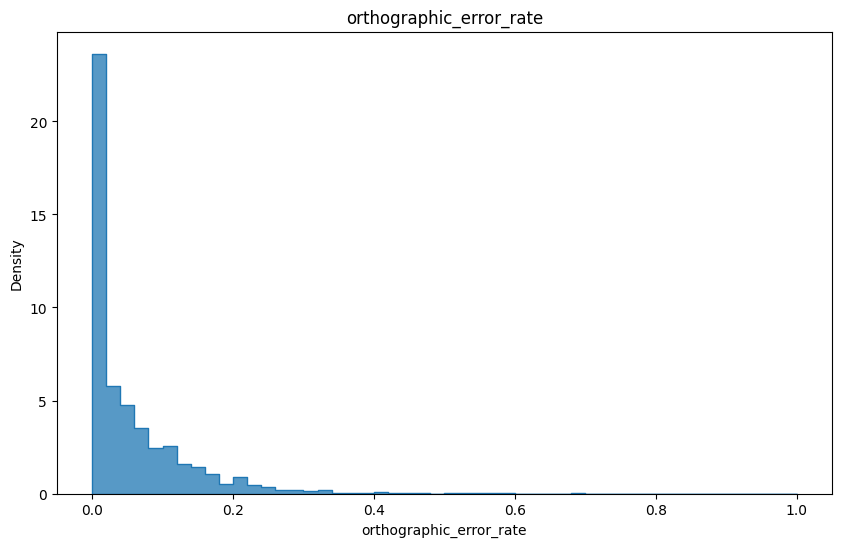

In [38]:
plot_data = df[['orthographic_error_rate']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="orthographic_error_rate",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('orthographic_error_rate')
plt.xlabel('orthographic_error_rate')
plt.ylabel("Density")

plt.show()

In [53]:
OER = 0.40

outliers_oer = df[df["orthographic_error_rate"] > OER]   

# print

pd.set_option("display.max_rows", None)

#print(outliers_oer)    # n=247

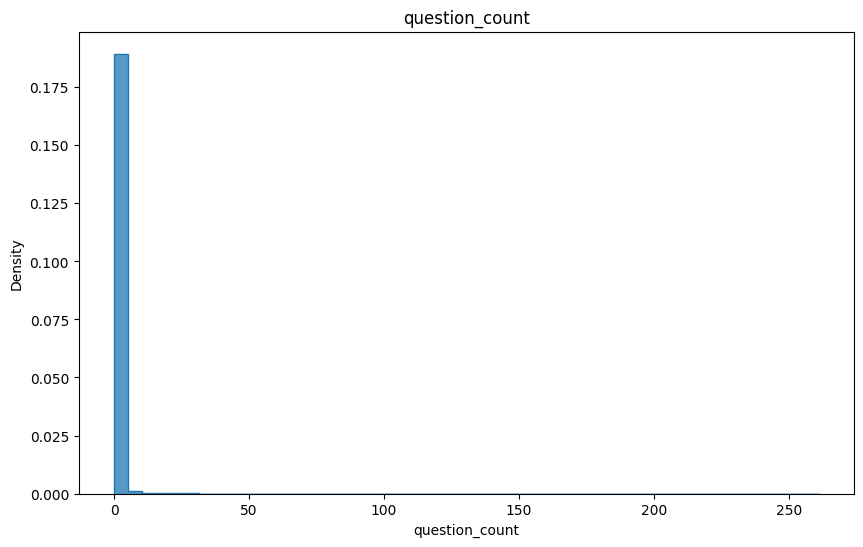

In [39]:
plot_data = df[['question_count']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="question_count",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('question_count')
plt.xlabel('question_count')
plt.ylabel("Density")

plt.show()

In [ ]:
QC=50

outliers_QC = df[df["question_count"] > QC]   

# print

pd.set_option("display.max_rows", None)

#print(outliers_QC)    # question_count should not be a feature, as sometimes prompts ask for transcription or translation, etc.

### topic and task features

In [22]:
# prompt_style

prompt_style_summary = df.groupby("prompt_style").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


prompt_style_summary

,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
prompt_style,,,,,,,,,,
other,27917,43.00,342.00,342.00,0.85,0.19,0.01,0.27,0.00,0.05
question,20381,32.00,282.00,282.00,0.87,0.11,0.00,0.23,1.68,0.05
instruction,9231,22.00,412.00,412.00,0.86,0.02,0.03,0.20,0.00,0.05


In [23]:
# task_type

task_type_summary = df.groupby("task_type").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


task_type_summary


,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
task_type,,,,,,,,,,
general_assistance,23355,21.00,289.00,289.00,0.88,0.05,0.00,0.16,0.48,0.06
writing_generation,10732,41.50,379.00,379.00,0.81,0.13,0.00,0.24,0.30,0.04
coding,10030,85.00,574.00,574.00,0.87,0.16,0.01,0.39,0.88,0.07
explanation,5534,23.00,256.00,256.00,0.92,0.12,0.06,0.21,1.06,0.04
brainstorming,2264,61.00,327.50,327.50,0.87,0.24,0.00,0.30,0.49,0.03
email_writing,1650,255.00,321.00,321.00,0.83,0.22,0.00,0.41,1.00,0.05
translation,1500,65.00,363.50,363.50,0.81,0.26,0.01,0.34,0.56,0.03
summarization,1340,205.00,211.00,211.00,0.89,0.30,0.01,0.49,0.94,0.04
roleplay,1124,61.00,192.00,192.00,0.71,0.86,0.00,0.22,0.25,0.03


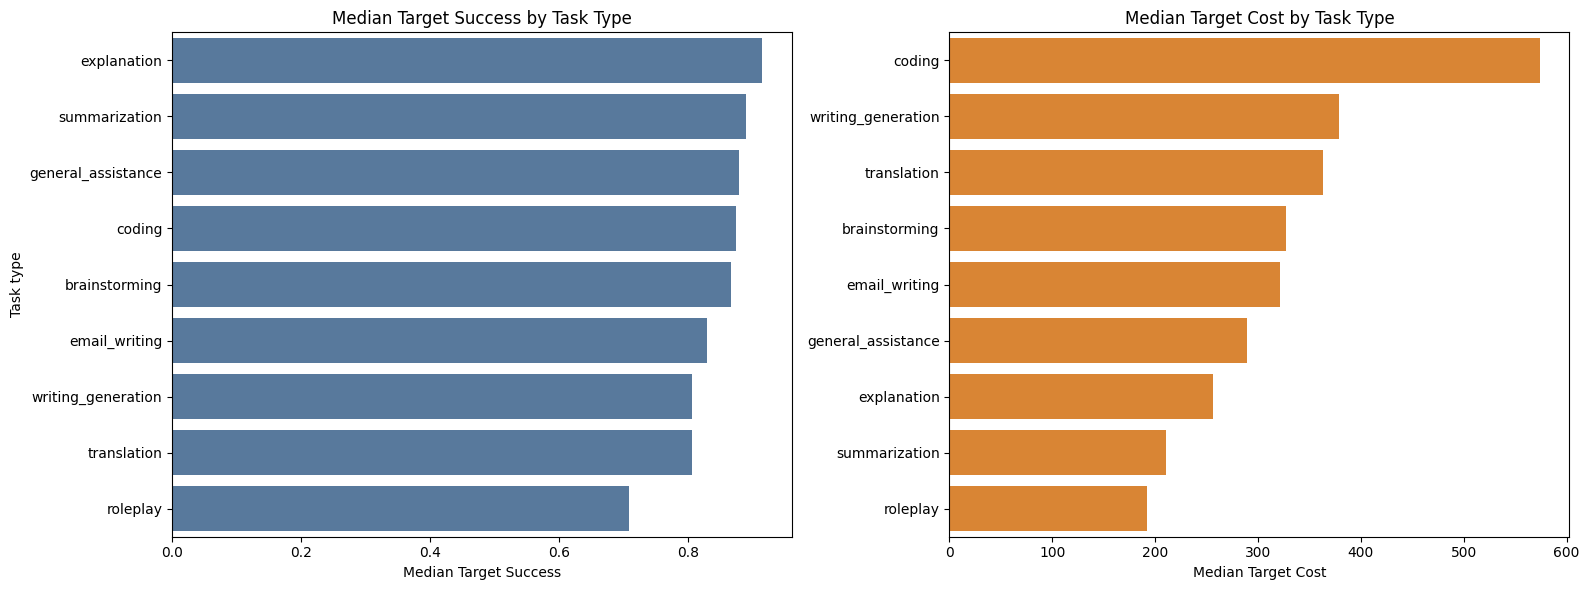

In [ ]:
plot_df = task_type_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("mean_target_success", ascending=False),
    x="mean_target_success",
    y="task_type",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Median Target Success by Task Type")
axes[0].set_xlabel("Median Target Success")
axes[0].set_ylabel("Task type")

sns.barplot(
    data=plot_df.sort_values("median_target_cost", ascending=False),
    x="median_target_cost",
    y="task_type",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Median Target Cost by Task Type")
axes[1].set_xlabel("Median Target Cost")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [64]:
# topic features
#'topic', 'topic_prob', 'topic_label', 'embedding_novelty', 'topic_confidence', 'is_generic_topic', 'topic_size', 'topic_size_log'

topic_labels_given = {
    -1: "Outlier / Noise",
     0: "ChatGPT / Writing / Data Usage",
     1: "Travel / Trips",
     2: "Time / Duration Tracking",
     3: "Cooking / Recipes",
     4: "Git / GitHub Development",
     5: "Medical / Clinical Data",
     6: "Math / Equations",
}

df["topic_name"] = df["topic"].map(topic_labels_given)

# topic_label

topic_label_1_summary = df.groupby("topic_name").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


topic_label_1_summary.head(10)


,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
topic_name,,,,,,,,,,
Outlier / Noise,30054,33.00,329.00,329.00,0.87,0.13,0.01,0.25,0.61,0.05
ChatGPT / Writing / Data Usage,22662,36.00,329.00,329.00,0.83,0.15,0.01,0.26,0.55,0.06
Travel / Trips,589,38.00,391.00,391.00,0.93,0.16,0.00,0.19,0.39,0.03
Time / Duration Tracking,431,51.00,153.00,153.00,0.92,0.02,0.00,0.07,0.94,0.01
Cooking / Recipes,337,25.00,374.00,374.00,0.90,0.14,0.00,0.23,0.34,0.03
Git / GitHub Development,262,23.00,540.50,540.50,0.93,0.02,0.00,0.16,0.62,0.09
Medical / Clinical Data,219,43.00,253.00,253.00,0.95,0.12,0.00,0.16,0.83,0.05
Math / Equations,204,25.50,252.00,252.00,0.88,0.05,0.00,0.05,0.52,0.02


In [67]:
# topic_label

topic_label_2_summary = df.groupby("topic_name").agg(
    conversations=("conversation_id", "count"),
    mean_novelty=("embedding_novelty", "mean"), 
    mean_confidence=("topic_confidence", "mean"),
    mean_generic=("is_generic_topic", "mean"),
    mean_topic_size=("topic_size", "mean")
).sort_values("conversations", ascending=False)


topic_label_2_summary.head(10)

,conversations,mean_novelty,mean_confidence,mean_generic,mean_topic_size
topic_name,,,,,
Outlier / Noise,30054,0.76,0.40,0.00,30054.00
ChatGPT / Writing / Data Usage,22662,0.74,0.75,1.00,22662.00
Travel / Trips,589,0.80,0.36,0.00,589.00
Time / Duration Tracking,431,0.87,0.31,0.00,431.00
Cooking / Recipes,337,0.82,0.56,0.00,337.00
Git / GitHub Development,262,0.91,0.42,0.00,262.00
Medical / Clinical Data,219,0.94,0.54,0.00,219.00
Math / Equations,204,0.85,0.62,0.00,204.00


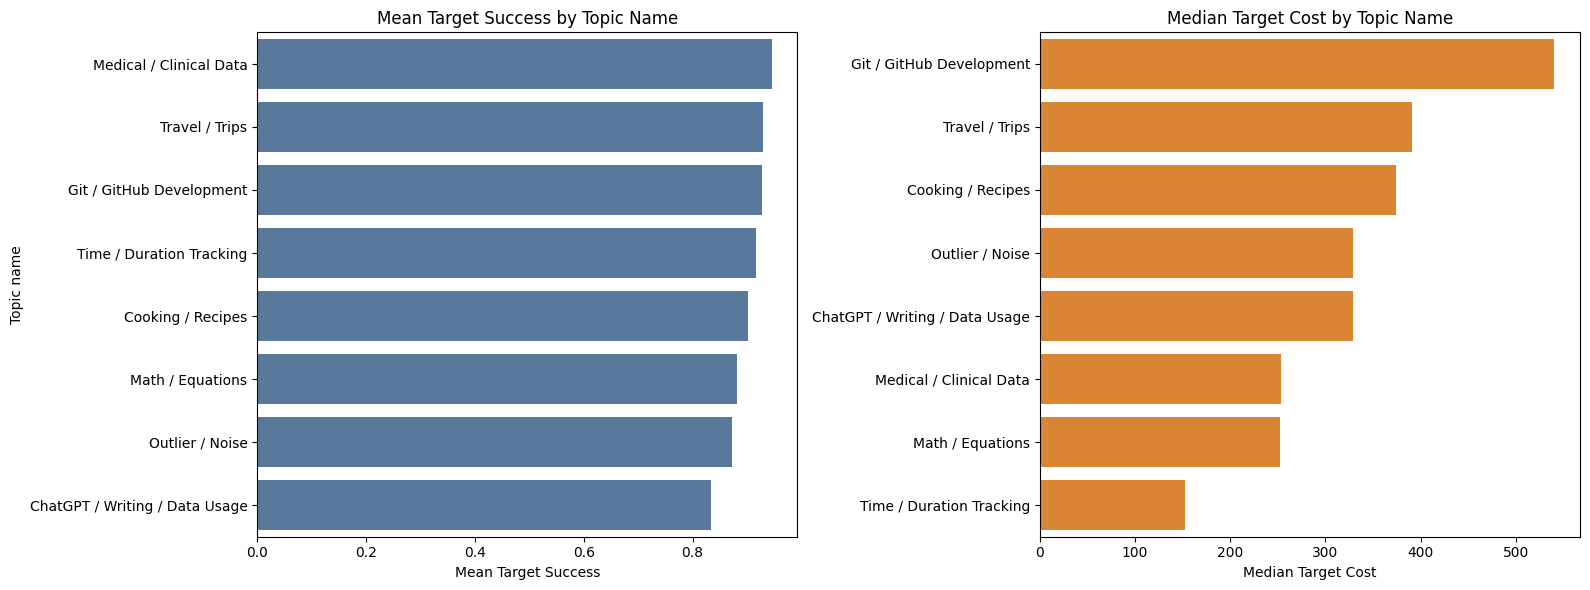

In [80]:
plot_df = topic_label_summary.reset_index()

# > 200 conversations
plot_df = plot_df[plot_df["conversations"] >= 200]

#plot_df = topic_label_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("mean_target_success", ascending=False),
    x="mean_target_success",
    y="topic_name",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Mean Target Success by Topic Name")
axes[0].set_xlabel("Mean Target Success")
axes[0].set_ylabel("Topic name")

sns.barplot(
    data=plot_df.sort_values("median_target_cost", ascending=False),
    x="median_target_cost",
    y="topic_name",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Median Target Cost by Topic Name")
axes[1].set_xlabel("Median Target Cost")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [79]:
pd.crosstab(df["topic_name"], df["task_type"])

task_type,brainstorming,coding,email_writing,explanation,general_assistance,roleplay,summarization,translation,writing_generation
topic_name,,,,,,,,,
ChatGPT / Writing / Data Usage,910,4498,744,1938,8453,440,616,700,4363
Cooking / Recipes,32,9,1,21,227,3,0,6,38
Git / GitHub Development,1,72,3,17,131,0,1,1,36
Math / Equations,3,2,2,61,121,2,0,0,13
Medical / Clinical Data,10,15,0,37,110,10,3,4,30
Outlier / Noise,1125,4862,863,2950,12447,614,687,736,5770
Time / Duration Tracking,2,3,0,59,350,0,0,6,11
Travel / Trips,127,17,7,27,315,15,4,6,71


# targets

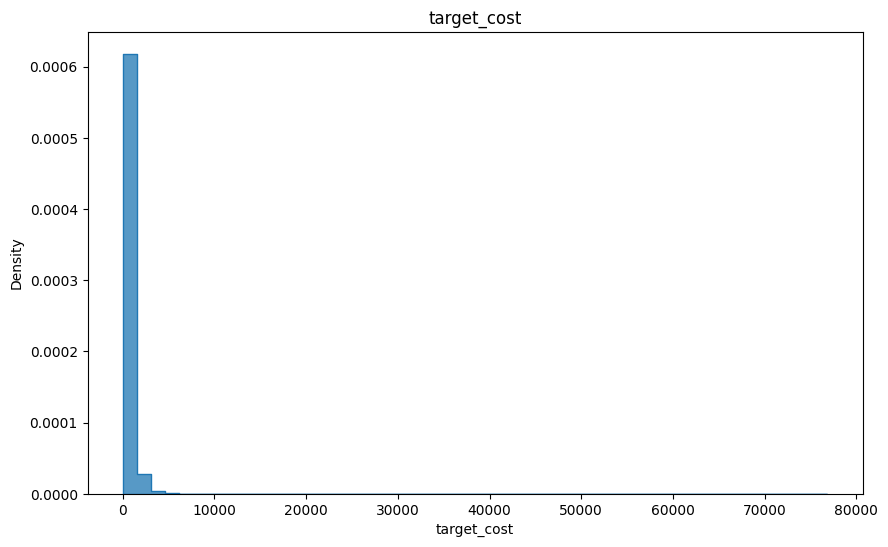

In [ ]:
#'target_cost'

plot_data = df[['target_cost']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="target_cost",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('target_cost')
plt.xlabel('target_cost')
plt.ylabel("Density")

plt.show()

In [83]:
df["target_cost_log"] = np.log1p(df["target_cost"])                  # highly skewed (but plausible), therefore log


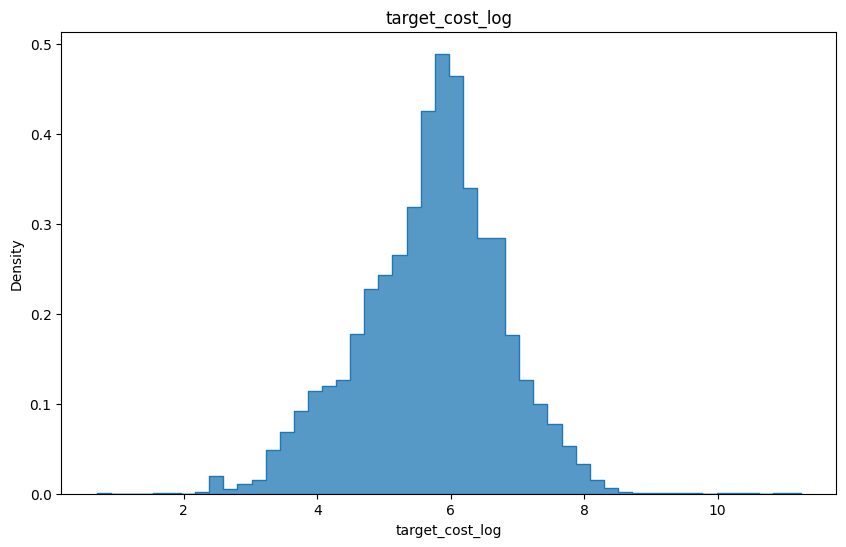

In [84]:
#'"target_cost_log"'

plot_data = df[["target_cost_log"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="target_cost_log",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('target_cost_log')
plt.xlabel('target_cost_log')
plt.ylabel("Density")

plt.show()

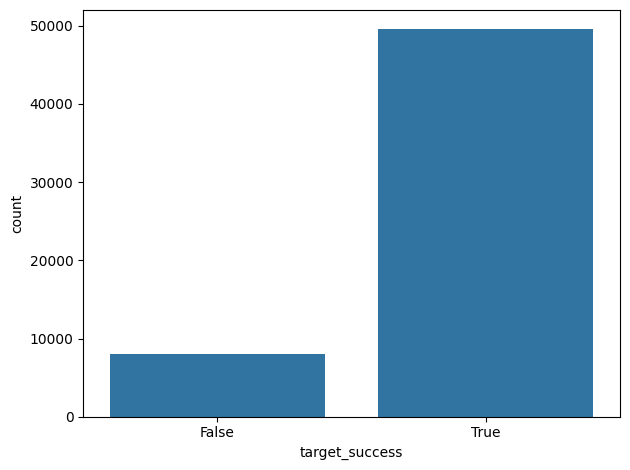

In [75]:
# 'target_success'

sns.countplot(data=df, x="target_success")
axes.set_title("target_success")
axes.set_xlabel("target_success")
axes.set_ylabel("Count")

plt.tight_layout()
plt.show()   
plt.show()

Results

- remove question_count (not clear enough as feature with counting questionmarks in first response; what about translations or transcripts,etc?)
- orthographic error rate for cleaner text (some other languages are still included; differentiation to translation, code, etc. is complicated)
- target "target_success" needs balancing in the models
- target "target_cost" is highly skewed, therefore "target_cost_log" as new target

In [87]:
base_path = Path(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features_target.csv"
)

base_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(base_path, index=False)